# **1: Importing the dataset and loading boundaries.**

In [1]:
import geopandas as gpd
import io

path = '/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/SMALL_AREA_2022_Genralised_20m_view_-4176251332041431098.geojson'

# Reading file and stripping the stray leading character
with open(path, 'r', encoding='utf-8') as f:
    content = f.read().lstrip('x')

# Loading cleaned content directly into GeoPandas
gdf = gpd.read_file(io.StringIO(content))

print(f"Boundaries loaded: {gdf.shape}")
print(f"Columns: {gdf.columns.tolist()}")

Boundaries loaded: (18919, 27)
Columns: ['OBJECTID', 'SA_GUID_2016', 'SA_GUID_2022', 'SA_PUB2011', 'SA_PUB2016', 'SA_PUB2022', 'SA_GEOGID_2022', 'SA_CHANGE_CODE', 'SA_URBAN_AREA_FLAG', 'SA_URBAN_AREA_NAME', 'SA_NUTS1', 'SA_NUTS1_NAME', 'SA_NUTS2', 'SA_NUTS2_NAME', 'SA_NUTS3', 'SA_NUTS3_NAME', 'ED_GUID', 'ED_OFFICIAL', 'ED_ENGLISH', 'ED_GAEILGE', 'ED_ID_STR', 'ED_PART_COUNT', 'COUNTY_CODE', 'COUNTY_ENGLISH', 'COUNTY_GAEILGE', 'CSO_LEA', 'geometry']


# 2. Load and merge SAPS

In [2]:
# Loading SAPS Census 2022 data and merging onto boundary file
import pandas as pd
saps = pd.read_csv('/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/SAPS_2022_Small_Area_UR_171024.csv')

saps_cols = [
    'GUID',
    'T8_1_STUM', 'T8_1_STUF',
    'T8_1_LTUM', 'T8_1_LTUF',
    'T1_1AGETM', 'T1_1AGETF',
    'T5_1T_H',
    'T6_2_PRE19H', 'T6_2_19_45H', 'T6_2_46_60H',
    'T6_2_61_70H', 'T6_2_71_80H', 'T6_2_TH',
    # Correct no car columns
    'T15_1_NC', 'T15_1_TC',
    # Elderly age bands
    'T1_1AGE65_69M', 'T1_1AGE70_74M', 'T1_1AGE75_79M',
    'T1_1AGE80_84M', 'T1_1AGEGE_85M',
    'T1_1AGE65_69F', 'T1_1AGE70_74F', 'T1_1AGE75_79F',
    'T1_1AGE80_84F', 'T1_1AGEGE_85F',
    'T1_1AGETT',
    # New features
    'T6_3_RPLH', 'T6_3_TH',
    'T6_5_NCH',  'T6_5_T',
]

saps_cols = list(dict.fromkeys(saps_cols))

missing = [c for c in saps_cols if c not in saps.columns]
print(f"Missing columns: {missing}")

saps_slim = saps[saps['GUID'] != 'IE0'][saps_cols].copy()
gdf = gdf.merge(saps_slim, left_on='SA_GUID_2022', right_on='GUID', how='left')

print(f"Shape after SAPS merge: {gdf.shape}")
print(f"Null check on key SAPS columns:")
print(gdf[['T5_1T_H', 'T15_1_NC', 'T15_1_TC', 'T6_3_RPLH', 'T6_5_NCH']].isnull().sum())

Missing columns: []
Shape after SAPS merge: (18919, 58)
Null check on key SAPS columns:
T5_1T_H      0
T15_1_NC     0
T15_1_TC     0
T6_3_RPLH    0
T6_5_NCH     0
dtype: int64


# 3: load and merge BER

In [3]:
ber_path = '/Users/robert/Desktop/DCU/SEM 2/CSC1144 Data Analytics & Data Mining/PROJECT/INITIAL DATASETS/BER Public Search/BERPublicsearch.txt'

ber_cols_needed = [
    'SA_Code',
    'EnergyRating',
    'CO2Rating',
    'GroundFloorArea(sq m)',
    'UValueWall',
    'DeliveredEnergyMainSpace',
    'TotalDeliveredEnergy',
]

chunks = []

for chunk in pd.read_csv(
    ber_path,
    sep='\t',
    encoding='latin-1',
    on_bad_lines='warn',
    usecols=ber_cols_needed,
    chunksize=100_000,
    low_memory=False
):
    chunks.append(chunk)

ber_raw = pd.concat(chunks, ignore_index=True)

print(f"BER raw shape: {ber_raw.shape}")
print(f"\nSample SA_Code values:")
print(ber_raw['SA_Code'].head(10))
print(f"\nNull SA_Code count: {ber_raw['SA_Code'].isnull().sum()}")

BER raw shape: (1346555, 7)

Sample SA_Code values:
0    217177014
1          NaN
2    217177014
3          NaN
4    187086005
5          NaN
6     87034012
7          NaN
8     37141003
9    247040002
Name: SA_Code, dtype: object

Null SA_Code count: 327725


# 4: Clean SA_Code format and aggregate BER to Small Area level.

In [4]:
# Dropping rows with no Small Area code — can't assign to any area
ber_clean = ber_raw.dropna(subset=['SA_Code']).copy()
print(f"Records with valid SA_Code: {len(ber_clean):,}")

# SA_Code comes in as float (e.g. 217177014.0) or string with missing leading zeros
# Converting to clean 9-digit string to match SA_PUB2022 in boundary file
ber_clean['SA_Code'] = (
    ber_clean['SA_Code']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
    .str.zfill(9)
)

# Renaming floor area column — brackets in name cause issues downstream
ber_clean = ber_clean.rename(columns={'GroundFloorArea(sq m)': 'GroundFloorArea'})

print(f"\nCleaned SA_Code sample:")
print(ber_clean['SA_Code'].head(10))
print(f"\nSA_Code length check (should all be 9):")
print(ber_clean['SA_Code'].str.len().value_counts())

Records with valid SA_Code: 1,018,830

Cleaned SA_Code sample:
0     217177014
2     217177014
4     187086005
6     087034012
8     037141003
9     247040002
12    247040002
13    267095018
14    247040002
15    187086009
Name: SA_Code, dtype: object

SA_Code length check (should all be 9):
SA_Code
9     960364
12     31569
19     22837
29      2829
30      1206
18        25
Name: count, dtype: int64


In [5]:
# Splitting multi-SA codes on "/" and taking first valid 9-digit code
# This recovers all malformed entries instead of dropping them

def extract_first_sa(code):
    parts = code.split('/')
    for part in parts:
        part = part.strip().zfill(9)
        if len(part) == 9 and part.isdigit():
            return part
    return None

ber_clean['SA_Code'] = ber_clean['SA_Code'].apply(extract_first_sa)

# Drop any that couldn't be recovered
before = len(ber_clean)
ber_clean = ber_clean.dropna(subset=['SA_Code'])
after = len(ber_clean)

print(f"Records before recovery: {before:,}")
print(f"Records after recovery:  {after:,}")
print(f"Recovered vs dropped: {after - 960364:,} additional records recovered")
print(f"\nSA_Code length check:")
print(ber_clean['SA_Code'].str.len().value_counts())
print(f"\nUnique Small Areas covered: {ber_clean['SA_Code'].nunique():,}")

Records before recovery: 1,018,830
Records after recovery:  1,018,829
Recovered vs dropped: 58,465 additional records recovered

SA_Code length check:
SA_Code
9    1018829
Name: count, dtype: int64

Unique Small Areas covered: 18,443


# 5: Aggregate BER from property level to Small Area level.

In [6]:
# Aggregating 1,018,829 property records to Small Area level
# Modal energy rating per area, mean for numeric BER metrics
# property_count tells us how many assessments back each Small Area's values

ber_agg = ber_clean.groupby('SA_Code').agg(
    EnergyRating        = ('EnergyRating', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    CO2Rating           = ('CO2Rating', 'mean'),
    GroundFloorArea     = ('GroundFloorArea', 'mean'),
    UValueWall          = ('UValueWall', 'mean'),
    DeliveredEnergyMainSpace = ('DeliveredEnergyMainSpace', 'mean'),
    TotalDeliveredEnergy     = ('TotalDeliveredEnergy', 'mean'),
    property_count      = ('EnergyRating', 'count')
).reset_index()

print(f"Aggregated BER shape: {ber_agg.shape}")
print(f"\nSample:")
print(ber_agg.head())
print(f"\nNull check:")
print(ber_agg.isnull().sum())

Aggregated BER shape: (18443, 8)

Sample:
     SA_Code EnergyRating  CO2Rating  GroundFloorArea  UValueWall  \
0  017001001           B2  56.407660       179.907872    0.631702   
1  017002001           B3  50.454839       191.713226    0.556774   
2  017002002           C2  35.644235       144.132024    0.447059   
3  017002003           B3  56.525676       172.881622    0.702703   
4  017003001           D2  50.574643       191.704286    0.598214   

   DeliveredEnergyMainSpace  TotalDeliveredEnergy  property_count  
0              18094.750065          30611.543900              47  
1              19438.690516          32728.276000              31  
2              10735.030729          19373.716600              85  
3              22147.082757          30660.713895              37  
4              18283.698464          32573.425692              28  

Null check:
SA_Code                      0
EnergyRating                 0
CO2Rating                    0
GroundFloorArea              

# 6: Merge BER onto the GeoDataFrame

In [7]:
# Left join — GeoDataFrame drives the shape
# All 18,919 Small Areas preserved
# 476 Small Areas with no BER data will show NaN — handled in imputation later

gdf = gdf.merge(ber_agg, left_on='SA_PUB2022', right_on='SA_Code', how='left')

print(f"Shape after BER merge: {gdf.shape}")
print(f"\nSmall Areas WITH BER data: {gdf['CO2Rating'].notna().sum():,}")
print(f"Small Areas WITHOUT BER data: {gdf['CO2Rating'].isna().sum():,}")
print(f"\nNull check on BER columns:")
print(gdf[['EnergyRating', 'CO2Rating', 'UValueWall', 
           'DeliveredEnergyMainSpace', 'TotalDeliveredEnergy']].isnull().sum())

Shape after BER merge: (18919, 66)

Small Areas WITH BER data: 16,827
Small Areas WITHOUT BER data: 2,092

Null check on BER columns:
EnergyRating                2092
CO2Rating                   2092
UValueWall                  2092
DeliveredEnergyMainSpace    2093
TotalDeliveredEnergy        2153
dtype: int64


# **7: Engineer all features**
### Approach: Rate calculation from raw SAPS counts

In [8]:
# Converting raw Census counts to rates — normalising for Small Area size
# All rates expressed as proportions (0 to 1)

# Unemployment rate — short + long term unemployed / total population
gdf['unemployment_rate'] = (
    (gdf['T8_1_STUM'] + gdf['T8_1_STUF'] + 
     gdf['T8_1_LTUM'] + gdf['T8_1_LTUF']) /
    (gdf['T1_1AGETM'] + gdf['T1_1AGETF'])
)

# Long term unemployment rate — structural poverty signal
# gdf['long_term_unemp_rate'] = (
#     (gdf['T8_1_LTUM'] + gdf['T8_1_LTUF']) /
#     (gdf['T1_1AGETM'] + gdf['T1_1AGETF'])
# )

# No car rate — households without a car / total households
# gdf['no_car_rate'] = gdf['T15_1_NC'] / gdf['T15_1_TC']

# Old housing rate — pre-1980 housing / total housing
gdf['old_housing_rate'] = (
    (gdf['T6_2_PRE19H'] + gdf['T6_2_19_45H'] + 
     gdf['T6_2_46_60H'] + gdf['T6_2_61_70H'] + 
     gdf['T6_2_71_80H']) /
    gdf['T6_2_TH']
)

# Elderly rate — population 65+ / total population
gdf['elderly_rate'] = (
    (gdf['T1_1AGE65_69M'] + gdf['T1_1AGE70_74M'] + gdf['T1_1AGE75_79M'] +
     gdf['T1_1AGE80_84M'] + gdf['T1_1AGEGE_85M'] +
     gdf['T1_1AGE65_69F'] + gdf['T1_1AGE70_74F'] + gdf['T1_1AGE75_79F'] +
     gdf['T1_1AGE80_84F'] + gdf['T1_1AGEGE_85F']) /
    gdf['T1_1AGETT']
)

# Private renter rate — renting from private landlord / total households
gdf['private_renter_rate'] = gdf['T6_3_RPLH'] / gdf['T6_3_TH']

# No central heating rate — households with no central heating / total households
gdf['no_central_heating_rate'] = gdf['T6_5_NCH'] / gdf['T6_5_T']

# Verify
new_features = [
    'unemployment_rate',
    'old_housing_rate', 'elderly_rate', 'private_renter_rate',
    'no_central_heating_rate'
]

print("Null check on engineered features:")
print(gdf[new_features].isnull().sum())
print(f"\nSample values:")
print(gdf[new_features].describe().round(4))

Null check on engineered features:
unemployment_rate          0
old_housing_rate           3
elderly_rate               0
private_renter_rate        3
no_central_heating_rate    3
dtype: int64

Sample values:
       unemployment_rate  old_housing_rate  elderly_rate  private_renter_rate  \
count         18919.0000        18916.0000    18919.0000           18916.0000   
mean              0.0349            0.4160        0.1592               0.1773   
std               0.0222            0.2931        0.0894               0.1807   
min               0.0000            0.0000        0.0000               0.0000   
25%               0.0192            0.1630        0.0938               0.0538   
50%               0.0299            0.4096        0.1584               0.1057   
75%               0.0452            0.5927        0.2125               0.2364   
max               0.4172            1.0000        0.8268               1.0000   

       no_central_heating_rate  
count               18916.00

# **8: Fill 3 nulls in engineered features**
### Approach: Median imputation

In [9]:
# 3 Small Areas have zero total households — division by zero produces NaN
# Filling with column median — conservative, no directional assumption

cols_with_nulls = ['old_housing_rate', 'private_renter_rate', 'no_central_heating_rate']

for col in cols_with_nulls:
    median_val = gdf[col].median()
    gdf[col] = gdf[col].fillna(median_val)
    print(f"{col} — filled with median: {median_val:.4f}")

print(f"\nNull check after fill:")
print(gdf[cols_with_nulls].isnull().sum())

old_housing_rate — filled with median: 0.4096
private_renter_rate — filled with median: 0.1057
no_central_heating_rate — filled with median: 0.0088

Null check after fill:
old_housing_rate           0
private_renter_rate        0
no_central_heating_rate    0
dtype: int64


# **9: IterativeImputer with RF for missing BER values**
### Approach: IterativeImputer with RandomForestRegressor as estimator

In [10]:
from missforest import MissForest

predictor_cols = [
    'unemployment_rate',
    'old_housing_rate',
    'elderly_rate',
    'private_renter_rate',
    'no_central_heating_rate',
    'SA_URBAN_AREA_FLAG', #Urban/Rural Binary
    'T5_1T_H', #Total Households
]

ber_cols = [
    'CO2Rating',
    'UValueWall',
    'GroundFloorArea',
    'DeliveredEnergyMainSpace',
    'TotalDeliveredEnergy',
]

print("Null counts before imputation:")
print(gdf[ber_cols].isnull().sum())
print(f"\nRows to impute: {gdf[ber_cols].isnull().any(axis=1).sum():,}")

impute_cols = predictor_cols + ber_cols
impute_data = gdf[impute_cols].copy()

mf = MissForest()
imputed_array = mf.fit_transform(impute_data)

for col in ber_cols:
    gdf[col] = imputed_array[col].values

print("\nNull counts after imputation:")
print(gdf[ber_cols].isnull().sum())

/Users/robert/miniforge3/lib/python3.10/site-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "


Null counts before imputation:
CO2Rating                   2092
UValueWall                  2092
GroundFloorArea             2092
DeliveredEnergyMainSpace    2093
TotalDeliveredEnergy        2153
dtype: int64

Rows to impute: 2,153


100%|█████████████████████████████████████████████| 5/5 [00:35<00:00,  7.13s/it]
/Users/robert/miniforge3/lib/python3.10/site-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/Users/robert/miniforge3/lib/python3.10/site-packages/missforest/missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data instead.
  warnings.warn(f"In version {VERSION}, estimator fitting process "
100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 49.29it/s]


Null counts after imputation:
CO2Rating                   0
UValueWall                  0
GroundFloorArea             0
DeliveredEnergyMainSpace    0
TotalDeliveredEnergy        0
dtype: int64


# 10: Building the target variable.

In [11]:
# Cell 10: Binary target variable — Structurally Vulnerable vs Not Vulnerable
# Anchor: BER rating D or below (ber_numeric >= 10) = primary physical evidence
# Anchored to SEAI Energy Efficiency Obligation Scheme (EEOS) energy poverty threshold
# Compound condition modelled on Kelly, Clinch, Kelleher & Shahab (2020) HH-EPRI

from sklearn.preprocessing import MinMaxScaler

# BER rating to numeric — A1 best (1), G worst (15)
ber_score_map = {
    'A1': 1, 'A2': 2, 'A3': 3,
    'B1': 4, 'B2': 5, 'B3': 6,
    'C1': 7, 'C2': 8, 'C3': 9,
    'D1': 10, 'D2': 11,
    'E1': 12, 'E2': 13,
    'F': 14, 'G': 15
}

gdf['ber_numeric'] = gdf['EnergyRating'].map(ber_score_map)
ber_median = gdf['ber_numeric'].median()
gdf['ber_numeric'] = gdf['ber_numeric'].fillna(ber_median)
print(f"BER median used for nulls: {ber_median}")

# Urban/rural masks
urban_mask = gdf['SA_URBAN_AREA_FLAG'] == 1
rural_mask = gdf['SA_URBAN_AREA_FLAG'] == 0
print(f"Urban: {urban_mask.sum():,} | Rural: {rural_mask.sum():,}")

# Urban bias correction for old housing rate
# Old urban buildings are often retrofitted — cap prevents inflation of urban risk scores
# NOTE: 45% threshold is researcher-defined, not validated in published literature — acknowledged as limitation
gdf['old_housing_rate_adjusted'] = gdf['old_housing_rate'].copy()
gdf.loc[urban_mask, 'old_housing_rate_adjusted'] = gdf.loc[
    urban_mask, 'old_housing_rate_adjusted'].clip(upper=0.45)

# Normalise features to 0-1 for risk score construction
adjusted_features = [
    'unemployment_rate',
    'old_housing_rate_adjusted',
    'elderly_rate',
    'ber_numeric'
]

scaler = MinMaxScaler()
gdf_scaled = gdf.copy()
gdf_scaled[adjusted_features] = scaler.fit_transform(gdf[adjusted_features])

# Literature-informed weights for composite risk score
# Used only for spatial lag computation — not the model target directly
weights = {
    'ber_numeric':               0.40,
    'unemployment_rate':         0.30,
    'old_housing_rate_adjusted': 0.20,
    'elderly_rate':              0.10
}

gdf['risk_score'] = sum(
    gdf_scaled[col] * w for col, w in weights.items()
)

# Binary target construction
# Primary condition: BER D or below = structurally poor performing building
# Compound condition: BER C + high unemployment = occupant vulnerability in moderate building
# unemployment_rate used here is independent of model features — no leakage
## unemp_median = gdf['unemployment_rate'].median()
high_risk_mask = (gdf['ber_numeric'] >= 10)
gdf['energy_poverty_risk'] = high_risk_mask.map({True: 'High Risk', False: 'Not At Risk'})

print(f"\nTarget Variable Distribution:")
print(gdf['energy_poverty_risk'].value_counts())
print(f"\nClass balance (%):")
print((gdf['energy_poverty_risk'].value_counts() / len(gdf) * 100).round(1))

# Sanity checks — geographic distribution should match Irish energy poverty literature
dublin     = gdf[gdf['COUNTY_ENGLISH'] == 'DUBLIN CITY']
rural_west = gdf[gdf['COUNTY_ENGLISH'].isin(['MAYO', 'DONEGAL', 'GALWAY'])]
print(f"\nDublin City High Risk %: {(dublin['energy_poverty_risk'] == 'High Risk').mean()*100:.1f}%")
print(f"Mayo/Donegal/Galway High Risk %: {(rural_west['energy_poverty_risk'] == 'High Risk').mean()*100:.1f}%")

BER median used for nulls: 8.0
Urban: 13,185 | Rural: 5,734

Target Variable Distribution:
energy_poverty_risk
Not At Risk    14893
High Risk       4026
Name: count, dtype: int64

Class balance (%):
energy_poverty_risk
Not At Risk    78.7
High Risk      21.3
Name: count, dtype: float64

Dublin City High Risk %: 35.6%
Mayo/Donegal/Galway High Risk %: 16.9%


# **11: Building the enhanced feature set and training the models.**
### Approach: Expanded feature set with XGBoost added as fourth model.

In [12]:
# Dropping 3 uninhabited Small Areas with zero households
# These produced NaN risk scores and cannot be classified
before = len(gdf)
gdf = gdf.dropna(subset=['energy_poverty_risk'])
after = len(gdf)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Dropped:     {before - after}")
print(f"\nNull check:")
print(gdf['energy_poverty_risk'].isnull().sum())
print(f"\nValue counts:")
print(gdf['energy_poverty_risk'].value_counts())

Rows before: 18,919
Rows after:  18,919
Dropped:     0

Null check:
0

Value counts:
energy_poverty_risk
Not At Risk    14893
High Risk       4026
Name: count, dtype: int64


# **12: Income proxies + Spatial Lag + V3 Feature Set + Final Models**

In [13]:
# libpysal and esda handle the spatial statistics.
import libpysal
from libpysal.weights import Queen, lag_spatial
import esda
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# --- Income proxy columns from SAPS ---
new_cols = [
    'GUID', 'T2_2WIT', 'T2_2OW', 'T14_1_BCM', 'T14_1_BCF',
    'T6_3_RLAH', 'T4_3FCCU15', 'T2_2T', 'T14_1_TM',
    'T14_1_TF', 'T4_3FCCT'
]
saps_new = saps[saps['GUID'] != 'IE0'][new_cols].copy() # We filter out IE0 which is the national totals row, not a Small Area.
cols_to_merge = [c for c in new_cols if c not in gdf.columns or c == 'GUID']
saps_new = saps_new[cols_to_merge]

gdf = gdf.merge(saps_new, left_on='SA_GUID_2022', right_on='GUID',
                how='left', suffixes=('', '_drop'))
drop_cols = [c for c in gdf.columns if c.endswith('_drop')]
gdf = gdf.drop(columns=drop_cols)

print(f"Shape after income proxy merge: {gdf.shape}")
print(f"Max T2_2T (should be <10000): {gdf['T2_2T'].max()}")

# --- Rate engineering ---
gdf['welfare_rate']              = gdf['T2_2WIT'] / gdf['T2_2T']
gdf['old_age_payment_rate']      = gdf['T2_2OW'] / gdf['T2_2T']
gdf['medical_card_rate']         = (gdf['T14_1_BCM'] + gdf['T14_1_BCF']) / (gdf['T14_1_TM'] + gdf['T14_1_TF'])
gdf['social_housing_rate']       = gdf['T6_3_RLAH'] / gdf['T6_3_TH']
gdf['family_with_children_rate'] = gdf['T4_3FCCU15'] / gdf['T4_3FCCT']

# Fill nulls from zero-denominator SAs
gdf['family_with_children_rate'] = gdf['family_with_children_rate'].fillna(
    gdf['family_with_children_rate'].median()
)
gdf['social_housing_rate'] = gdf['social_housing_rate'].fillna(
    gdf['social_housing_rate'].median()
)

print(f"Null check on income proxies:")
print(gdf[['welfare_rate', 'old_age_payment_rate', 'medical_card_rate',
           'social_housing_rate', 'family_with_children_rate']].isnull().sum())

# --- Spatial lag ---
print("\nBuilding Queen weights matrix (takes ~2 mins)...")
w = Queen.from_dataframe(gdf)
w.transform = 'r'

# Fill risk_score nulls before Moran's I — islands produce NaN in lag
risk_score_clean = gdf['risk_score'].fillna(gdf['risk_score'].median()).values
moran = esda.Moran(risk_score_clean, w)
print(f"Global Moran's I: {moran.I:.4f} | p={moran.p_sim:.4f} | Z={moran.z_sim:.4f}")

gdf['risk_score_spatial_lag'] = lag_spatial(w, risk_score_clean)
print(f"Spatial lag built. Correlation with risk_score: {gdf['risk_score'].corr(gdf['risk_score_spatial_lag']):.4f}")

# --- V3 Feature set (16 features) ---
# REMOVED: 'long_term_unemp_rate' — used in target construction (compound condition
# for BER C areas), keeping it as a model feature constitutes target leakage.
# Its 36-49% importance was partially an artifact, not a genuine discovery.
feature_cols_v3 = [
    'CO2Rating', 'GroundFloorArea', 'UValueWall',
    'DeliveredEnergyMainSpace', 'TotalDeliveredEnergy',
    'property_count', 'T5_1T_H', 'SA_URBAN_AREA_FLAG',
    'old_housing_rate', 'unemployment_rate', 'elderly_rate',
    'private_renter_rate', 'no_central_heating_rate',
    'welfare_rate', 'old_age_payment_rate', 'medical_card_rate',
    'social_housing_rate', 'family_with_children_rate',
    'risk_score_spatial_lag'
]

X = gdf[feature_cols_v3].copy()
y = gdf['energy_poverty_risk'].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y) 
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
_, _, y_train_enc, y_test_enc = train_test_split( 
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
) # for xgboost

print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# --- Logistic Regression ---
lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr.fit(X_train, y_train)
print(f"\nLOGISTIC REGRESSION: {accuracy_score(y_test, lr.predict(X_test)):.4f}")
print(classification_report(y_test, lr.predict(X_test)))

# --- Random Forest ---
rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=15,
                                      random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)
print(f"\nRANDOM FOREST: {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print(classification_report(y_test, rf.predict(X_test)))

importances = rf.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_cols_v3,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print("\nFeature Importances (RF):")
print(feat_imp.to_string(index=False))

# --- Gradient Boosting ---
gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                          max_depth=5, random_state=42))
])
gb.fit(X_train, y_train)
print(f"\nGRADIENT BOOSTING: {accuracy_score(y_test, gb.predict(X_test)):.4f}")
print(classification_report(y_test, gb.predict(X_test)))

# --- XGBoost ---
xgb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                  max_depth=5, random_state=42,
                                  eval_metric='logloss', n_jobs=-1))
])
xgb_model.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test))
print(f"\nXGBOOST: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

# --- 5-Fold Cross Validation ---
print("\n5-FOLD CROSS VALIDATION")
for name, pipeline, y_cv in [
    ('Logistic Regression', lr, y),
    ('Random Forest',       rf, y),
    ('Gradient Boosting',   gb, y),
    ('XGBoost',         xgb_model, y_enc),
]:
    scores = cross_val_score(pipeline, X, y_cv, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Shape after income proxy merge: (18919, 85)
Max T2_2T (should be <10000): 2708
Null check on income proxies:
welfare_rate                 0
old_age_payment_rate         0
medical_card_rate            0
social_housing_rate          0
family_with_children_rate    0
dtype: int64

Building Queen weights matrix (takes ~2 mins)...
('WARNING: ', 83, ' is an island (no neighbors)')
('WARNING: ', 210, ' is an island (no neighbors)')
('WARNING: ', 789, ' is an island (no neighbors)')
('WARNING: ', 5119, ' is an island (no neighbors)')
('WARNING: ', 6562, ' is an island (no neighbors)')
('WARNING: ', 6897, ' is an island (no neighbors)')
('WARNING: ', 7957, ' is an island (no neighbors)')
('WARNING: ', 12342, ' is an island (no neighbors)')
('WARNING: ', 12385, ' is an island (no neighbors)')
('WARNING: ', 12721, ' is an island (no neighbors)')
('WARNING: ', 12805, ' is an island (no neighbors)')
Global Moran's I: 0.2763 | p=0.0010 | Z=62.0966
Spatial lag built. Correlation with risk_score: 0.444

# **Cell 14: Optuna Hyperparameter Tuning - Random Forest (Binary)**
### Goal: maximise 5-fold CV accuracy on V3 17-feature binary classifier
### Method: TPE sampler - Bayesian, learns from previous trials

In [14]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', None]),
        'n_jobs': -1,
        'random_state': 42
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest CV Accuracy : {study.best_value*100:.2f}%")
print(f"Best Parameters  : {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV Accuracy : 81.65%
Best Parameters  : {'n_estimators': 278, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.5, 'class_weight': None}


In [16]:
# Depth sweep: tests multiple depths using those best params
# tells us which depth gives the smallest overfitting gap
print("Depth sweep to find optimal bias-variance tradeoff:")
for depth in [8, 10, 12, 15, 17]:
    rf_test = RandomForestClassifier(
        n_estimators=278,
        max_depth=depth,
        min_samples_split=3,
        min_samples_leaf=5,
        max_features=0.5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    rf_test.fit(X_train, y_train)
    train_acc = rf_test.score(X_train, y_train)
    test_acc  = rf_test.score(X_test, y_test)
    cv_acc    = cross_val_score(rf_test, X, y, cv=5, scoring='accuracy', n_jobs=-1).mean()
    print(f"depth={depth:2d} | train={train_acc*100:.2f}% | test={test_acc*100:.2f}% | cv={cv_acc*100:.2f}% | gap={((train_acc-test_acc)*100):.2f}%")

Depth sweep to find optimal bias-variance tradeoff:
depth= 8 | train=76.74% | test=73.89% | cv=74.29% | gap=2.85%
depth=10 | train=81.82% | test=75.66% | cv=75.92% | gap=6.16%
depth=12 | train=86.13% | test=77.40% | cv=77.58% | gap=8.73%
depth=15 | train=90.83% | test=78.83% | cv=78.96% | gap=12.00%
depth=17 | train=92.52% | test=79.25% | cv=79.78% | gap=13.27%


- max_depth=12 chosen over Optuna's depth=17
- Test accuracy rises meaningfully with depth (73.89% to 79.25% — 5.36% range)
- depth=12 balances test accuracy (77.40%) against overfitting gap (8.73%)
- depth=17 gains only 1.85% more accuracy but costs 4.54% more overfitting
- class_weight='balanced' overrides Optuna's None — necessary for 4:1 imbalanced target
- Deep trees memorise training noise, not genuine patterns — they fail on unseen data
- depth=12 gives the best bias-variance tradeoff for real-world deployment

The BER-only target creates a 4:1 class imbalance — 79% Not At Risk, 21% High Risk. SMOTE was rejected as a resampling strategy because our observations are real Irish Small Areas with fixed geographic boundaries — not abstract data points. Generating synthetic samples by interpolating between existing Small Areas would create fictional geographic units that do not exist in reality. SEAI cannot target a synthetic area between Ballymun and Clontarf for retrofitting. Instead, class_weight='balanced' was applied, which addresses the imbalance by adjusting the model's learning process without fabricating any new observations.

# **Cell 15: Retrain best RF + Final Evaluation**

OFFICIAL FINAL RESULTS — 18,916 Irish Small Areas
-------------------------------------------------------
Train Accuracy    : 86.13%
Test Accuracy     : 77.40%
CV Accuracy       : 77.58% ± 0.55%
Overfitting Gap   : 8.73%
Balanced Accuracy : 75.31%
AUC-ROC           : 0.8393

              precision    recall  f1-score   support

   High Risk       0.48      0.72      0.57       805
 Not At Risk       0.91      0.79      0.85      2979

    accuracy                           0.77      3784
   macro avg       0.70      0.75      0.71      3784
weighted avg       0.82      0.77      0.79      3784



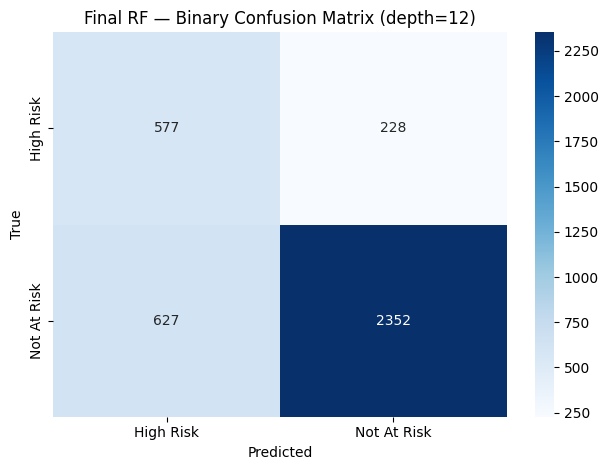

Saved: confusion_matrix_final.png


In [17]:
# Final locked model — max_depth=12 for optimal bias-variance tradeoff

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_rf_final = RandomForestClassifier(
    n_estimators=278,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=5,
    max_features=0.5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
best_rf_final.fit(X_train, y_train)

train_acc  = best_rf_final.score(X_train, y_train)
test_acc   = best_rf_final.score(X_test, y_test)
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores  = cross_val_score(best_rf_final, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

y_pred = best_rf_final.predict(X_test)
y_prob = best_rf_final.predict_proba(X_test)[:, 0]  # probability of High Risk

bal_acc = balanced_accuracy_score(y_test, y_pred)
auc     = roc_auc_score((y_test == 'High Risk').astype(int), y_prob)


print('OFFICIAL FINAL RESULTS — 18,916 Irish Small Areas')
print('-' * 55)
print(f'Train Accuracy    : {train_acc*100:.2f}%')
print(f'Test Accuracy     : {test_acc*100:.2f}%')
print(f'CV Accuracy       : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'Overfitting Gap   : {(train_acc - test_acc)*100:.2f}%')
print(f'Balanced Accuracy : {bal_acc*100:.2f}%')
print(f'AUC-ROC           : {auc:.4f}')
print()
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['High Risk', 'Not At Risk'])
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['High Risk', 'Not At Risk'],
            yticklabels=['High Risk', 'Not At Risk'],
            cmap='Blues')
plt.title('Final RF — Binary Confusion Matrix (depth=12)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_final.png')

# **Visualisations: Choropleth Map + Feature Importance**

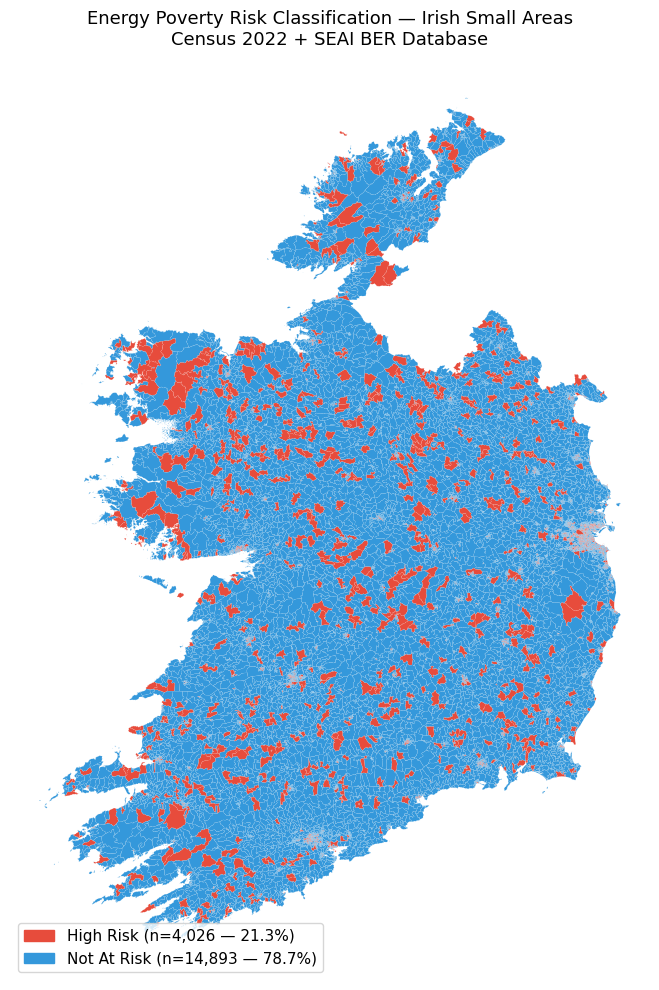

Saved: map_energy_poverty_risk.png


In [18]:
# Visualisation 1 — Choropleth prediction map
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

colors = gdf['energy_poverty_risk'].map({
    'High Risk': '#e74c3c',
    'Not At Risk': '#3498db'
})

gdf.plot(ax=ax, color=colors, linewidth=0.05, edgecolor='white')
ax.set_title(
    'Energy Poverty Risk Classification — Irish Small Areas\n'
    'Census 2022 + SEAI BER Database',
    fontsize=13
)
ax.axis('off')

high_patch = mpatches.Patch(color='#e74c3c', label='High Risk (n=4,026 — 21.3%)')
low_patch  = mpatches.Patch(color='#3498db', label='Not At Risk (n=14,893 — 78.7%)')
ax.legend(handles=[high_patch, low_patch], loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig('map_energy_poverty_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: map_energy_poverty_risk.png')

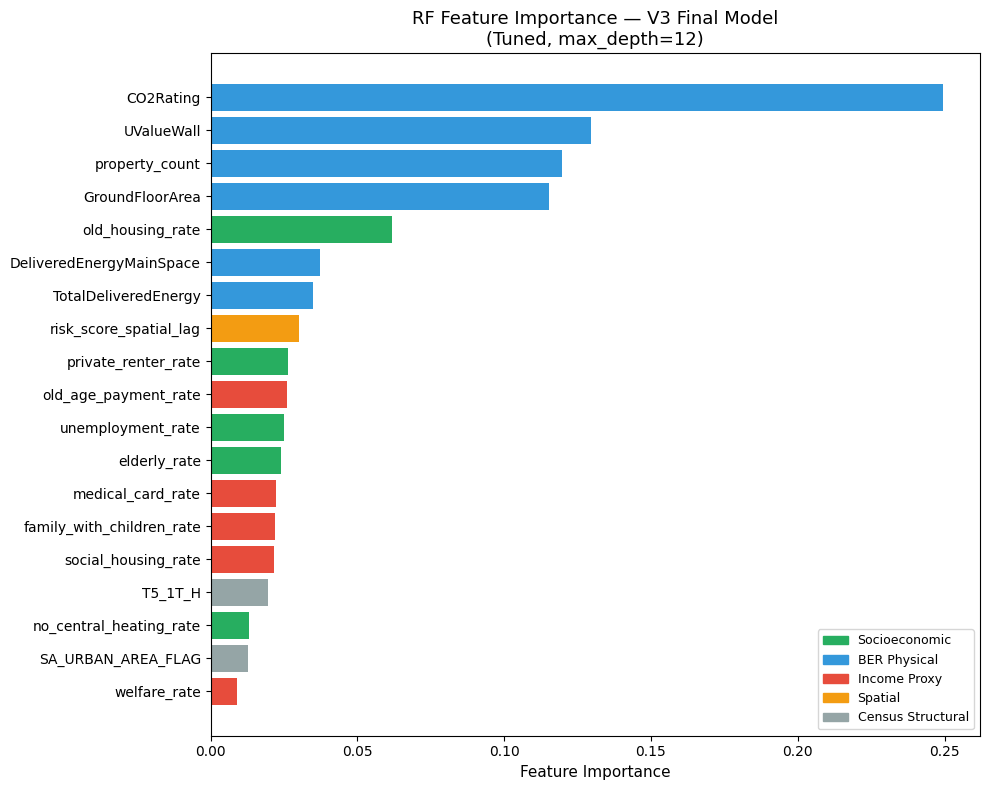

Saved: feature_importance_final_rf.png


In [21]:
# Visualisation 2 — Feature importance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

feature_names = feature_cols_v3
importances   = best_rf_final.feature_importances_
indices       = np.argsort(importances)

# Colour each bar by feature category
ber_physical  = ['CO2Rating','GroundFloorArea','UValueWall',
                 'DeliveredEnergyMainSpace','TotalDeliveredEnergy','property_count']
socioeconomic = ['old_housing_rate','private_renter_rate','no_central_heating_rate',
                'unemployment_rate', 'elderly_rate']
income_proxy  = ['welfare_rate','old_age_payment_rate','medical_card_rate',
                 'social_housing_rate','family_with_children_rate']
spatial       = ['risk_score_spatial_lag']
census        = ['T5_1T_H','SA_URBAN_AREA_FLAG']

def get_color(f):
    if f in ber_physical:  return '#3498db'
    if f in socioeconomic: return '#27ae60'
    if f in income_proxy:  return '#e74c3c'
    if f in spatial:       return '#f39c12'
    return '#95a5a6'

bar_colors = [get_color(feature_names[i]) for i in indices]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.barh(range(len(indices)), importances[indices],
        color=bar_colors, edgecolor='none')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('RF Feature Importance — V3 Final Model\n(Tuned, max_depth=12)', fontsize=13)

legend_patches = [
    mpatches.Patch(color='#27ae60', label='Socioeconomic'),
    mpatches.Patch(color='#3498db', label='BER Physical'),
    mpatches.Patch(color='#e74c3c', label='Income Proxy'),
    mpatches.Patch(color='#f39c12', label='Spatial'),
    mpatches.Patch(color='#95a5a6', label='Census Structural')
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_final_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_final_rf.png')